In [1]:
##############################
#OI HS Analysis              #
#Maintainer: Christopher Chan#
#Date: 2024-09-08            #
#Version: 0.1.7              #
##############################

import os
import pathlib
import matplotlib

import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.patches import FancyArrowPatch

data_feature = pathlib.Path("../data/04_feature")
data_output = pathlib.Path("../data/07_model_output")
fig_output = pathlib.Path("../docs/figures")

with open(f"{data_feature}/hash_r1_score.csv") as round_1:
    r1_df = pd.read_csv(round_1, sep = ",")
    r1_df.columns = [f"{col}_r1" if col not in ["Issue", "Issue_cat"] else col for col in r1_df.columns]

with open(f"{data_feature}/hash_r2_score.csv") as round_2:
    r2_df = pd.read_csv(round_2, sep = ",")
    r2_df.columns = [f"{col}_r2" if col not in ["Issue", "Issue_cat"] else col for col in r2_df.columns]

HS_combine = pd.merge(r1_df, r2_df, on=["Issue", "Issue_cat"], how="inner", suffixes=["_r1", "_r2"])
rank_cols = HS_combine.filter(regex="(?i)^rank", axis = 1).columns
HS_combine.drop(rank_cols, axis = 1, inplace = True)

In [2]:
misc_cols = HS_combine.filter(regex="rank|score").columns
HS_justScore = HS_combine.drop(columns = misc_cols, axis = 1)
HS_justScore = HS_justScore.drop(columns = ["Unnamed: 0_r1", "Unnamed: 0_r2"], axis = 1)

HS_justScore.sample(n = 8)

,Issue,Issue_cat,492e4b_r1,22338c_r1,9f1eb6_r1,04545f_r1,6d4470_r1,ed22ef_r1,540a7a_r1,708920_r1,...,3bf1fb_r2,540a7a_r2,3ee680_r2,22338c_r2,9f1eb6_r2,ed22ef_r2,d9bf00_r2,492e4b_r2,2a8c4a_r2,3b7706_r2
5,Deteriorating quality of the governance of nuc...,Government & Politics,801,637,310,201,777.7,770,895,907,...,100,300,301,560,490,300,450,733,555,730
30,Use of inadequate tools for climate risk asses...,Climate Environment & Ecology,395,859,318,158,583.0,550,232,246,...,74,555,376,532,200,667,512,300,354,788
7,AI and arms use; in bioengineering or arms races,Biosecurity,871,905,460,444,899.0,500,810,561,...,350,730,666,610,605,750,880,971,952,830
11,"Crisis, gridlock, and accelerating fragility",Government & Politics,679,931,391,578,570.1,711,690,587,...,570,385,411,616,190,400,830,598,385,788
3,Cascading loss of food system complexity causi...,Food Security,942,834,450,889,734.1,387,575,743,...,800,580,429,610,695,758,800,765,809,880
14,Recovery of global communication systems from ...,Systemic Risk,700,867,389,88,700.0,554,325,788,...,650,310,950,390,620,500,502,376,496,585
29,Collapse of economic growth,Economics,150,856,700,532,623.1,800,220,108,...,212,170,111,140,320,565,750,187,826,619
34,Change to a superrotating state of the atmosphere,Climate Environment & Ecology,490,485,40,5,750.0,445,540,555,...,420,100,814,90,50,250,200,135,593,400


In [3]:
HS_justScore.columns

Index(['Issue', 'Issue_cat', '492e4b_r1', '22338c_r1', '9f1eb6_r1',
       '04545f_r1', '6d4470_r1', 'ed22ef_r1', '540a7a_r1', '708920_r1',
       '9a2d12_r1', 'cdefc7_r1', 'd9bf00_r1', '3ee680_r1', 'e5ed2f_r1',
       '029745_r1', 'b59cd1_r1', '3bf1fb_r1', '04c88f_r1', 'e96af1_r1',
       '4f4fcd_r1', '53465a_r1', '3b7706_r1', '874d58_r1', 'fb235a_r1',
       '79bd39_r1', 'd2282d_r1', '7b9161_r1', 'fbb58e_r1', '2a8c4a_r1',
       '708920_r2', 'e96af1_r2', 'e5ed2f_r2', 'd6c710_r2', '874d58_r2',
       '9a2d12_r2', 'fbb58e_r2', 'd2282d_r2', '3bf1fb_r2', '540a7a_r2',
       '3ee680_r2', '22338c_r2', '9f1eb6_r2', 'ed22ef_r2', 'd9bf00_r2',
       '492e4b_r2', '2a8c4a_r2', '3b7706_r2'],
      dtype='object')

In [4]:
justScore_Ldf = pd.melt(HS_justScore, id_vars=["Issue", "Issue_cat"], var_name='Participant', value_name='Score')
justScore_Ldf["HS_round"] = justScore_Ldf["Participant"].str.extract('(_r\d)').replace({'_r1': 1, '_r2': 2})
justScore_Ldf["Participant"] = justScore_Ldf["Participant"].str.replace('(_r\d)', '', regex=True)
print(justScore_Ldf.loc[:, ['Score', 'HS_round']].groupby('HS_round').describe())

justScore_Ldf

          Score                                                            
          count        mean         std  min     25%    50%     75%     max
HS_round                                                                   
1         980.0  551.789898  251.463475  1.0  368.75  580.0  750.75   998.0
2         630.0  513.290476  254.206618  1.0  310.00  515.0  718.25  1000.0


/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/2774313551.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  justScore_Ldf["HS_round"] = justScore_Ldf["Participant"].str.extract('(_r\d)').replace({'_r1': 1, '_r2': 2})


,Issue,Issue_cat,Participant,Score,HS_round
0,Risk Accelerator: Integration of AI in Nuclear...,Nuclear Weapons,492e4b,650.0,1
1,Cracks in the foundation: critical transitions...,Climate Environment & Ecology,492e4b,855.0,1
2,Supercharged Surveillance States merged with p...,Government & Politics,492e4b,730.0,1
3,Cascading loss of food system complexity causi...,Food Security,492e4b,942.0,1
4,Status-Quo Path-Dependence by Elites merged wi...,Society,492e4b,400.0,1
...,...,...,...,...,...
1605,Use of inadequate tools for climate risk asses...,Climate Environment & Ecology,3b7706,788.0,2
1606,State Capacity Deficits,Government & Politics,3b7706,863.0,2
1607,Combination of natural and technological disas...,Systemic Risk,3b7706,589.0,2
1608,Catastrophic impacts from satellite megaconste...,Space,3b7706,888.0,2


/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always b


Modified WLS results: Nuclear Weapons
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.112
Model:                            WLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     5.557
Date:                Sat, 01 Aug 2026   Prob (F-statistic):             0.0229
Time:                        17:59:14   Log-Likelihood:                -313.01
No. Observations:                  46   AIC:                             630.0
Df Residuals:                      44   BIC:                             633.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")



Modified WLS results: Biosecurity
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.001
Model:                            WLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.07890
Date:                Sat, 01 Aug 2026   Prob (F-statistic):              0.779
Time:                        17:59:15   Log-Likelihood:                -630.88
No. Observations:                  92   AIC:                             1266.
Df Residuals:                      90   BIC:                             1271.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        607.

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always b


Modified WLS results: Economics
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.062
Model:                            WLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     2.908
Date:                Sat, 01 Aug 2026   Prob (F-statistic):             0.0952
Time:                        17:59:15   Log-Likelihood:                -320.09
No. Observations:                  46   AIC:                             644.2
Df Residuals:                      44   BIC:                             647.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        592.15

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")



Modified WLS results: Space
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.037
Model:                            WLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.687
Date:                Sat, 01 Aug 2026   Prob (F-statistic):              0.201
Time:                        17:59:15   Log-Likelihood:                -319.92
No. Observations:                  46   AIC:                             643.8
Df Residuals:                      44   BIC:                             647.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        392.5397  

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/3198355496.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


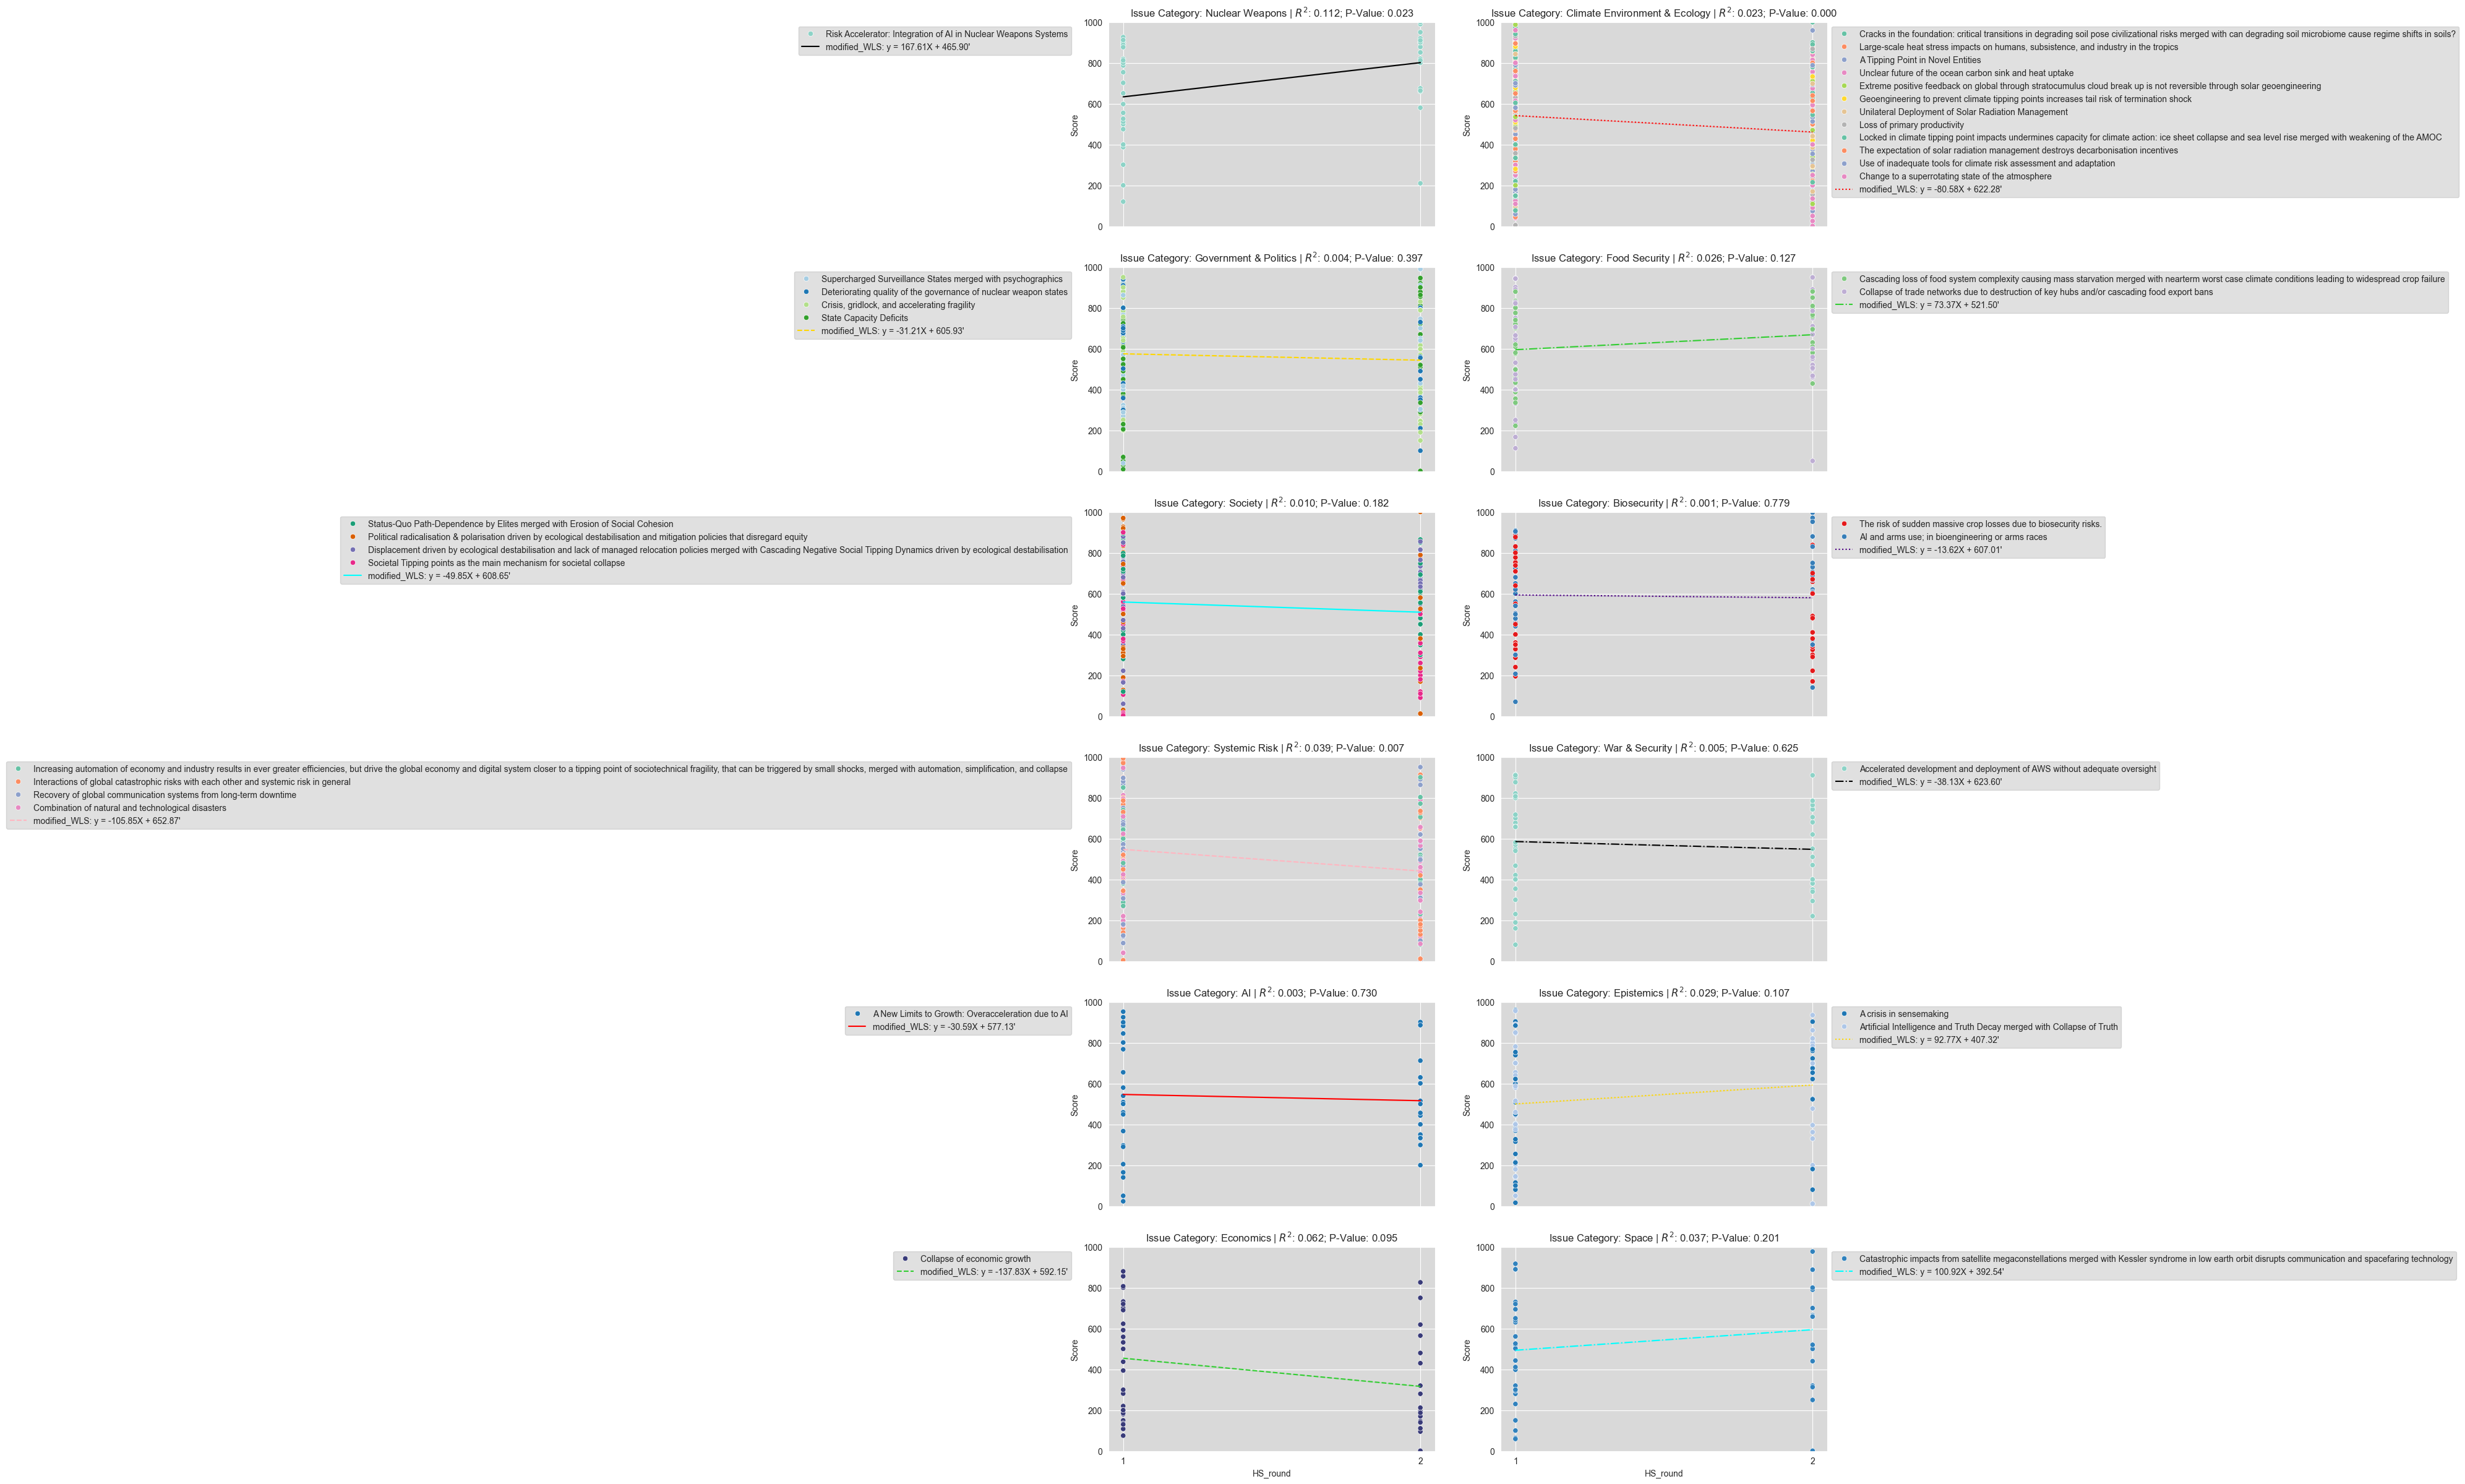

In [5]:
sns.set_style('darkgrid', {'axes.facecolor': '.85'})

fig, ax = plt.subplots(6, 2, figsize=(15, 30), sharex=True)

axes = ax.flatten()

r1_exp = []
r2_exp = []
var_round1 = []
var_round2 = []
r_squared = []
p_values = []


for idx, cat in enumerate(justScore_Ldf['Issue_cat'].unique()):
    palette_ls = ['Set3', 'Set2', 'Paired', 'Accent', 'Dark2', 'Set1',
                  'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c']
    linestyle_ls = ['solid', 'dotted', 'dashed', 'dashdot', 'solid',
                    'dotted', 'dashed', 'dashdot', 'solid', 'dotted',
                    'dashed', 'dashdot']
    colour_ls = ['black', 'red', 'gold', 'limegreen', 'cyan', 'indigo',
                 'lightpink', 'black', 'red', 'gold', 'limegreen', 'cyan']

    justScore_cat = justScore_Ldf[justScore_Ldf['Issue_cat'] == cat]

    # Inverse WLS that uses variance as weights
    y = justScore_cat['Score']
    x = justScore_cat['HS_round']
    X_sm = sm.add_constant(x)
    variance = justScore_cat.groupby('HS_round')['Score'].var()
    in_wt = justScore_cat['HS_round'].map(variance)

    # Create model, fit, and print results
    inv_WLS = sm.WLS(y, X_sm, weights = in_wt)
    res_inv = inv_WLS.fit()
    inv_ypred = res_inv.predict()
    print(f"\nModified WLS results: {cat}")
    print(res_inv.summary())

    # Fill DataFrame
    r1_exp.append(inv_ypred[0])
    var_round1.append(variance.loc[1])
    var_round2.append(variance.loc[2])
    r2_exp.append(inv_ypred[-1])
    r_squared.append(res_inv.rsquared)
    p_values.append(res_inv.pvalues["HS_round"])
    
    
    splot = sns.scatterplot(justScore_cat, x='HS_round', y='Score',
                            hue='Issue', ax=axes[idx], palette=palette_ls[idx])
    WLSplot = sns.lineplot(justScore_cat, x='HS_round', y=inv_ypred,
                           ax=axes[idx], linestyle=linestyle_ls[idx], color=colour_ls[idx],
                           label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")

    axes[idx].set_title(f"Issue Category: {cat} | $R^2$: {res_inv.rsquared:.3f}; P-Value: {res_inv.pvalues['HS_round']:.3f}")
    axes[idx].set_xticks([1, 2])
    axes[idx].set_ylim(1-1, 1000)

    if idx % 2 == 0:
        # Left side subplots
        axes[idx].legend(bbox_to_anchor = (-0.1, 1), ncol=1)
    else:
        # Right side subplots
        axes[idx].legend(bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.savefig(f"{fig_output}/WLSissueCat_subplots.png", bbox_inches="tight")
plt.show()

# DataFrame to collect inv_WLS ypred expected values
WLS_expDF = pd.DataFrame({
    "Issue_cat": justScore_Ldf["Issue_cat"].unique(),
    "round_1": r1_exp,
    "round1_variance": var_round1,
    "round_2": r2_exp,
    "round2_variance": var_round2,
    "r_squared": r_squared,
    "P-Value": p_values
})

In [6]:
WLS_expDF["Variance_change%"] = (WLS_expDF["round1_variance"] - WLS_expDF["round2_variance"]) / WLS_expDF["round1_variance"] * 100
WLS_expDF["Significant (crit: 0.1)"] = WLS_expDF["P-Value"] < 0.1
WLS_expDF

,Issue_cat,round_1,round1_variance,round_2,round2_variance,r_squared,P-Value,Variance_change%,Significant (crit: 0.1)
0,Nuclear Weapons,633.503571,54099.937394,801.111111,36148.692810,0.112139,0.022917,33.181637,True
1,Climate Environment & Ecology,541.704762,65061.837052,461.129630,63404.224978,0.023391,0.000310,2.547749,True
2,Government & Politics,574.721429,59292.356834,543.513889,59274.450509,0.003940,0.397289,0.030200,False
3,Food Security,594.876786,48864.835633,668.250000,33294.078571,0.025699,0.126890,31.864953,False
4,Society,558.805357,61309.136728,508.958333,54870.434859,0.009779,0.181710,10.502027,False
5,Biosecurity,593.392857,47062.242857,579.777778,61611.320635,0.000876,0.779441,-30.914544,False
6,Systemic Risk,547.017857,67088.504183,441.166667,60715.633803,0.039083,0.007146,9.499199,True
7,War & Security,585.464286,63672.183862,547.333333,41223.764706,0.005476,0.625012,35.256242,False
8,AI,546.535714,79394.850529,515.944444,46438.643791,0.002741,0.729694,41.509250,False
9,Epistemics,500.089286,71666.737338,592.861111,68245.608730,0.028599,0.107066,4.773663,False


In [7]:
WLS_expDF.to_csv("../data/07_model_output/WLS_results.csv", index=False)

In [8]:
WLS_expDF_L = pd.melt(WLS_expDF, id_vars="Issue_cat", value_vars=["round_1", "round_2"], var_name="HS_round", value_name="Expected_Score")

WLS_expDF_L

,Issue_cat,HS_round,Expected_Score
0,Nuclear Weapons,round_1,633.503571
1,Climate Environment & Ecology,round_1,541.704762
2,Government & Politics,round_1,574.721429
3,Food Security,round_1,594.876786
4,Society,round_1,558.805357
5,Biosecurity,round_1,593.392857
6,Systemic Risk,round_1,547.017857
7,War & Security,round_1,585.464286
8,AI,round_1,546.535714
9,Epistemics,round_1,500.089286


/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_22217/604860363.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",


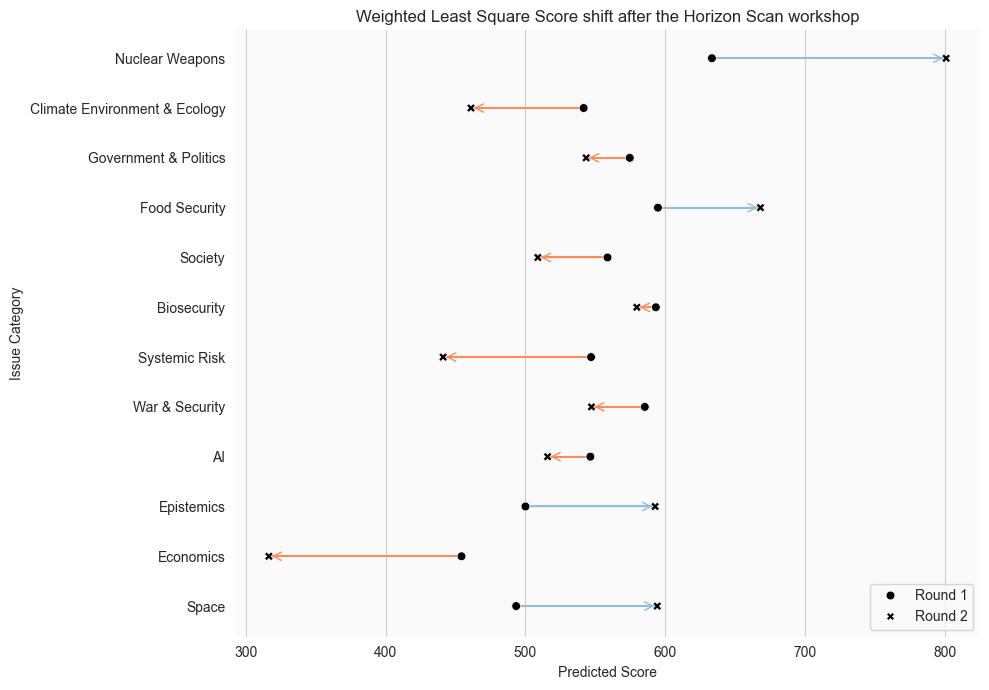

In [9]:
# Lollipop chart
sns.set_style('whitegrid', {'axes.facecolor': '0.98'})

fig, ax = plt.subplots(figsize = (10, 7))

#lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",
#                        hue="HS_round", palette="Set2")

for idx, cat in enumerate(WLS_expDF_L["Issue_cat"].unique()):
    temp_df = WLS_expDF_L[WLS_expDF_L["Issue_cat"] == cat]

    r1_score = temp_df[temp_df["HS_round"] == "round_1"]["Expected_Score"].values[0]
    r2_score = temp_df[temp_df["HS_round"] == "round_2"]["Expected_Score"].values[0]

    if r2_score > r1_score:
        cane_col = "#91bfdb"
        plt.gca().add_patch(FancyArrowPatch((r1_score, idx), (r2_score, idx),
                                       arrowstyle='->', color='#91bfdb', mutation_scale=15))
    else:
        cane_col = "#fc8d59"        
        plt.gca().add_patch(FancyArrowPatch((r2_score, idx), (r1_score, idx),
                                       arrowstyle='<-', color='#fc8d59', mutation_scale=15))


    sns.lineplot(temp_df, x="Expected_Score", y="Issue_cat",
                 color=cane_col, zorder=0)

lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",
                        color="#000000", palette="Set2", zorder=1,
                        style="HS_round", s=40)


lolli.yaxis.grid(False)
handles, _ = lolli.get_legend_handles_labels()
new_handles = ['Round 1', 'Round 2']
lolli.legend(handles, new_handles, loc="lower right")
#lolli.set_xlim(1, 1000)
plt.xticks(list(range(300, 900, 100)))

sns.despine(left=True, bottom=True)
plt.ylabel("Issue Category")
plt.xlabel("Predicted Score")
plt.title("Weighted Least Square Score shift after the Horizon Scan workshop")

plt.tight_layout()
plt.savefig(f"{fig_output}/Deliberation_lolli.png")
plt.show()